In [5]:
# The simple way in: name a player, a season, optionally which weeks. Whatever charts aren't
# already downloaded are fetched automatically - no image paths, no scrape/extract split.
from next_gen_scrapy import get_passes, get_routes, get_carries

passes = get_passes("Josh Allen", 2025, weeks=list(range(1,23)))   # every charted pass, those 3 weeks
passes.head()

looking up 2025 pass charts for Josh Allen, weeks 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 3, 4, 5, 6, 7, 8, 9...


/Users/ryan/Downloads/FF-Python-Analytics-master/next_gen_scrapy/player.py:106: UserWarning: no pass chart found for 'Josh Allen' in 2025, week(s): 18, 19, 20, 21, 22, 7, 8
  warnings.warn("no %s chart found for %r in %s, week(s): %s"
/Users/ryan/Downloads/FF-Python-Analytics-master/next_gen_scrapy/player.py:121: UserWarning: skipped ./Pass_Charts/BUF/2025/1/images/Allen_Joshua_QB.jpeg (week 1): CalibrationError('no field drawn: line-of-scrimmage bar not found')
  warnings.warn("skipped %s (week %s): %r" % (image_path, _scrape.week_label(meta), e))


,game_id,season,season_type,week,team,esb_id,name,position,pass_type,located,x_coord,y_coord
0,2025091406,2025,REG,2,BUF,ALL529264,Josh Allen,QB,COMPLETE,True,-13.54,16.90
1,2025091406,2025,REG,2,BUF,ALL529264,Josh Allen,QB,COMPLETE,True,-6.43,16.71
2,2025091406,2025,REG,2,BUF,ALL529264,Josh Allen,QB,COMPLETE,True,-7.45,11.01
3,2025091406,2025,REG,2,BUF,ALL529264,Josh Allen,QB,COMPLETE,True,14.58,6.04
4,2025091406,2025,REG,2,BUF,ALL529264,Josh Allen,QB,COMPLETE,True,8.68,5.78


In [2]:
# get_routes / get_carries work the same way, for a receiver / a running back.
# Rows are one point per point along the route/carry (0.5 yd spacing); group by
# (game_id, route_id) or (game_id, carry_id) for one row per route/carry.
routes = get_routes("Justin Jefferson", 2025, weeks=[1, 2, 3])
carries = get_carries("Bijan Robinson", 2025, weeks=[1, 2, 3])
print(routes.shape, carries.shape)
routes.head()

(971, 16) (1633, 16)


,game_id,season,season_type,week,team,esb_id,name,position,route_id,route_type,touchdown,start_ok,point,segment,x_coord,y_coord
0,2025090800,2025,REG,1,MIN,JEF269287,Justin Jefferson,WR,1,COMPLETE,False,True,0,route,-0.39,-1.7
1,2025090800,2025,REG,1,MIN,JEF269287,Justin Jefferson,WR,1,COMPLETE,False,True,1,route,-0.89,-1.7
2,2025090800,2025,REG,1,MIN,JEF269287,Justin Jefferson,WR,1,COMPLETE,False,True,2,route,-1.39,-1.7
3,2025090800,2025,REG,1,MIN,JEF269287,Justin Jefferson,WR,1,COMPLETE,False,True,3,route,-1.89,-1.7
4,2025090800,2025,REG,1,MIN,JEF269287,Justin Jefferson,WR,1,COMPLETE,False,True,4,route,-2.39,-1.7


In [3]:
carries.head()

,game_id,season,season_type,week,team,esb_id,name,position,carry_id,gain_class,touchdown,fumble_lost,handoff_ok,point,x_coord,y_coord
0,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,0,-5.40,-3.08
1,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,1,-5.87,-2.93
2,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,2,-6.34,-2.78
3,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,3,-6.81,-2.61
4,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,4,-7.27,-2.42


In [7]:
passes['week'].value_counts().sort_index()  # how many passes charted per week

week
2     21
3     27
4     20
5     29
6     26
9     25
10    38
11    27
12    32
13    22
14    27
15    26
16    18
17    36
Name: count, dtype: int64

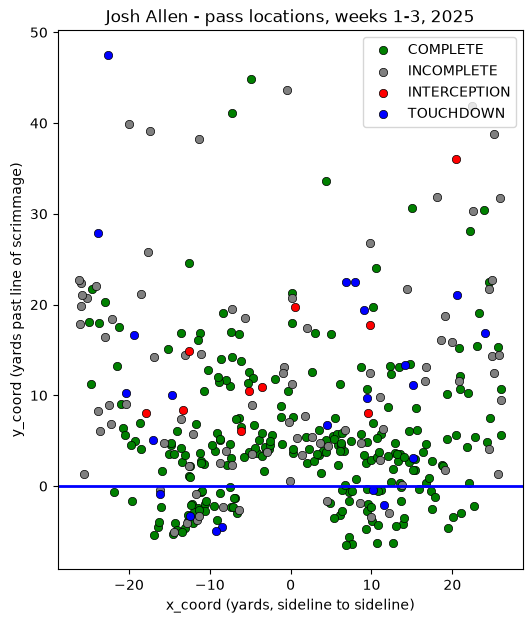

In [6]:
# Coordinates are real field yards now (x_coord, y_coord), not pixel positions - so a plain
# scatter is already meaningful: x is sideline-to-sideline, y is yards past the line of scrimmage.
import matplotlib.pyplot as plt

colors = {'COMPLETE': 'green', 'INCOMPLETE': 'gray', 'TOUCHDOWN': 'blue', 'INTERCEPTION': 'red'}
fig, ax = plt.subplots(figsize=(6, 7))
for ptype, d in passes[passes.located].groupby('pass_type'):
    ax.scatter(d['x_coord'], d['y_coord'], c=colors[ptype], label=ptype, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='blue', lw=2)   # line of scrimmage
ax.set_xlabel('x_coord (yards, sideline to sideline)')
ax.set_ylabel('y_coord (yards past line of scrimmage)')
ax.set_title('Josh Allen - pass locations, weeks 1-3, 2025')
ax.legend()
plt.show()